In [2]:
# makemore part 5

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [4]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {c: i+1 for i, c in enumerate(chars)}
stoi['.'] = 0
itos = {i: c for c, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(stoi)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [6]:
# shuffle the words
import random
random.seed(42)
random.shuffle(words)

In [7]:
# build the datasets
block_size = 8
def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])


In [8]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> e
.......e --> b
......eb --> r
.....ebr --> i
....ebri --> m
...ebrim --> a
..ebrima --> .
........ --> h
.......h --> i
......hi --> l
.....hil --> t
....hilt --> o
...hilto --> n
..hilton --> .
........ --> j
.......j --> h
......jh --> e
.....jhe --> n
....jhen --> e
...jhene --> .


In [9]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # kaimin init
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

# ------------------------------------------------------------------------------

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim, keepdim=True) # batch mean
            xvar = x.var(dim, keepdim=True, unbiased=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

# ------------------------------------------------------------------------------

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    
# ------------------------------------------------------------------------------

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, ix):
        self.out = self.weight[ix]
        return self.out
    
    def parameters(self):
        return [self.weight]
    
# ------------------------------------------------------------------------------

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape # Batch, Time, Channel
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
# ------------------------------------------------------------------------------

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

**FlattenConsectutive, look more explanation in the end of notebook.**

In [10]:
torch.manual_seed(42);

In [12]:
n_emb = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MPL

model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenConsecutive(2), Linear(n_emb * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
    # last layer, make less confident
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

76579


In [13]:
# looking at a batch of just 4 examples

ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0, 13,  1, 12,  9, 14,  1],
        [ 0,  0,  0,  0,  0,  0,  0,  1],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 18,  9]])

In [14]:
# checking out the dimensions layer by layer (especially important, batchnorm layer has a bug)
for layer in model.layers:
    print(f'{layer.__class__.__name__}:', tuple(layer.out.shape))

Embedding: (4, 8, 24)
FlattenConsecutive: (4, 4, 48)
Linear: (4, 4, 128)
BatchNorm1d: (4, 4, 128)
Tanh: (4, 4, 128)
FlattenConsecutive: (4, 2, 256)
Linear: (4, 2, 128)
BatchNorm1d: (4, 2, 128)
Tanh: (4, 2, 128)
FlattenConsecutive: (4, 256)
Linear: (4, 128)
BatchNorm1d: (4, 128)
Tanh: (4, 128)
Linear: (4, 27)


In [ ]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 128])

In [ ]:
model.layers[0].out.shape # output of embedding layer

torch.Size([22902, 8, 24])

In [ ]:
model.layers[1].out.shape # output of flatten layer

torch.Size([22902, 4, 48])

In [ ]:
model.layers[2].out.shape # output of linear layer

torch.Size([22902, 4, 128])

In [ ]:
# optimization
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update values
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/ 200000: 3.2330
  10000/ 200000: 1.8883
  20000/ 200000: 2.2478
  30000/ 200000: 1.9250
  40000/ 200000: 2.1944
  50000/ 200000: 2.0263
  60000/ 200000: 1.8202
  70000/ 200000: 2.0573
  80000/ 200000: 2.3311
  90000/ 200000: 2.0768
 100000/ 200000: 2.2061
 110000/ 200000: 1.6064
 120000/ 200000: 2.0350
 130000/ 200000: 2.0903
 140000/ 200000: 2.0504
 150000/ 200000: 2.2729
 160000/ 200000: 1.3368
 170000/ 200000: 1.9963
 180000/ 200000: 1.8604
 190000/ 200000: 1.6069


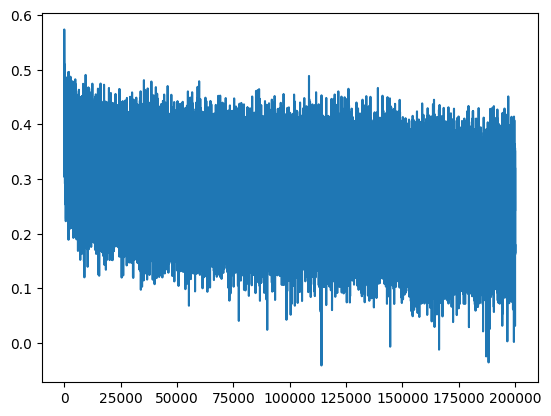

In [ ]:
plt.plot(lossi);

torch.Size([200])


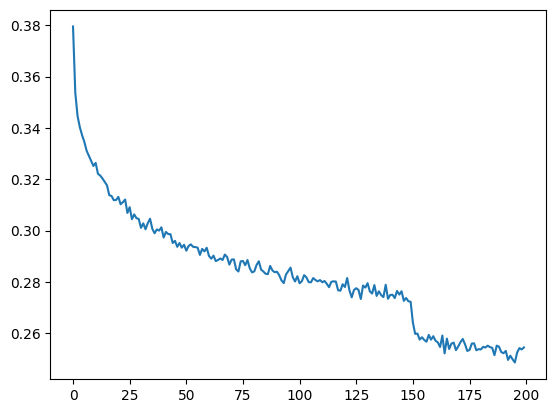

In [ ]:
# since batching might give a lucky strike in training, or not so lucky strike, it makes the training data loss visualization somewhat
# cramped looking from one batch to another. we could average out the data and plot that:
print(torch.tensor(lossi).view(-1, 1000).mean(1).shape)
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1));

In [ ]:
# put layers in eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training = False

In [ ]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('dev')


train 1.77023446559906
dev 1.9850441217422485


In [ ]:
# sample from the model

for i in range(20):
    out = []
    context = [0] * block_size
    while True:
        with torch.no_grad():
            logits = model(torch.tensor([context]))
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1).item()
            context = context[1:] + [ix]
            out.append(ix)
            if ix == 0:
                break
    print(''.join(itos[ix] for ix in out))

nakiyah.
martes.
kalim.
barioe.
myathika.
zhyri.
saiven.
zaniiah.
cathir.
terreim.
augliada.
maytons.
joba.
emerise.
breysie.
zion.
kaliah.
reelynn.
gia.
dra.


FlattenConsectutive

FlattenConsecutive(n) takes neighbouring time position and groups them togerther into a bigger feature vector (channel). For makemore:

emb.shape = (32, 8, 10)

32 = batch size
8 = context / time positions
10 = embedding features per character

then FlattenConsecutive(2): (32, 8, 10) --> (32, 4, 20)

because it groups chars into pairs:
1, 2, 3, 4, 5, 6, 7, 8 --> (1, 2), (3, 4), (5, 6), (7, 8)

So the general rule is (B, T, C) --> (B, T/n, C*n)

FlattenConsecutive(2) means keep the batch size, halve the time dimension and double the channel dimension.

For BatchNorm1d we want mean and variance per feature/channel, so x.mean(0) works for (B, C), but for (B, T, C) we need x.mean((0, 1)) because we average over both batch dimension and time dimension while keeping feature/channel dimension separate.


In [ ]:
x = torch.randn((2, 4, 8))
flat = FlattenConsecutive(2)
print(x.shape)
flat(x).shape

torch.Size([2, 4, 8])


torch.Size([2, 2, 16])

The point of this architecture is to build increasingly large context windows layer by layer, in a CNN-like way.

Instead of flattening the entire input immediately, the model first combines neighboring characters into small local groups, then combines those groups into larger groups, and eventually into one full context vector.

The same Linear layer weights are reused across all time positions at a given level. For example, the first Linear layer is applied with the same weights to all 4 character-pair groups, and the second Linear layer is applied with the same weights to both half-context groups.

In this implementation, FlattenConsecutive(2) creates non-overlapping neighboring groups:


(1, 2), (3, 4), (5, 6), (7, 8) --> (1, 2, 3, 4), (5, 6, 7, 8) --> (1, 2, 3, 4, 5, 6, 7, 8)

A standard CNN often uses overlapping sliding windows, while this implementation uses non-overlapping groups. This hierarchical local-to-global grouping is what makes the architecture WaveNet-like.

In [33]:
a = torch.randn(32,8,10)

print(a.mean(0).shape)
print(a.mean((0,1)).shape)
print(a.mean((0,1,2)))

torch.Size([8, 10])
torch.Size([10])
tensor(-0.0064)
